In [21]:
!pip install pandasql

In [22]:
import numpy as np
import pandas as pd
import os

In [23]:
customer_df = pd.read_csv('ecommerce_customer_analytics.csv')
print(f"The dataset has been successfully loaded. Total data: {customer_df.shape[0]} baris dan {customer_df.shape[1]} kolom.")
customer_df.head()

The dataset has been successfully loaded. Total data: 1200 baris dan 25 kolom.


,customer_id,age,gender,country,region,income_bracket,signup_date,last_purchase_date,customer_lifetime_days,days_since_last_purchase,...,device_type,loyalty_tier,discount_usage_rate,return_rate,newsletter_subscribed,referral_source,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
0,CUST-00001,35,Male,United States,North America,"$75,000–$99,999",2022-10-17,2024-11-13,759,48,...,Desktop,Platinum,0.229,0.084,False,Social Media,10.2,6.4,4,0
1,CUST-00002,58,Male,Germany,Europe,"$25,000–$49,999",2020-12-05,2024-04-24,1237,251,...,Mobile,Gold,0.349,0.019,True,Social Media,1.0,6.9,5,0
2,CUST-00003,43,Female,Australia,Asia-Pacific,"$75,000–$99,999",2019-05-27,2022-10-25,1248,798,...,Desktop,Platinum,0.186,0.117,True,Paid Ad,7.4,1.1,3,1
3,CUST-00004,54,Male,United Kingdom,Europe,"$25,000–$49,999",2022-02-23,2023-08-15,539,504,...,Mobile,Gold,0.048,0.130,True,Referral,14.4,5.8,5,1
4,CUST-00005,30,Male,Brazil,Latin America,"Under $25,000",2021-06-09,2022-04-28,324,978,...,Mobile,Bronze,0.056,0.085,True,Email Campaign,5.7,4.3,5,1


# **Data Cleaning**

In [24]:
print("--- START DATA CLEANING ---")
# 1. Check which columns have missing values
missing_data = customer_df.isnull().sum()
print("Total Number of missing values in each column:")
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No Missing Values")

# 2. Fill in empty text/categorical fields with 'Unknown'
categorical_cols = customer_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  if customer_df[col].isnull().sum() > 0:
    customer_df[col] = customer_df[col].fillna('Unknown')

#3. Fill empty numeric cells with the median value
numerical_cols = customer_df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
  if customer_df[col].isnull().sum() > 0:
    median_value = customer_df[col].median()
    customer_df[col] = customer_df[col].fillna(median_value)

#4. Checking for and handling duplicate data
duplicate_count = customer_df.duplicated().sum()
print(f"Total Number of duplicate rows: {duplicate_count}")
if duplicate_count > 0:
  customer_df = customer_df.drop_duplicates(inplace=True)
  print("Duplicate rows have been removed.")

#5. DATA TYPE CONVERSION (Converting text to Date/Datetime type)
customer_df['signup_date'] = pd.to_datetime(customer_df['signup_date'])
customer_df['last_purchase_date'] = pd.to_datetime(customer_df['last_purchase_date'])
print('The date column data type has been successfully changed to Datetime.')

print("--- DATA CLEANING COMPLETE ---")


--- START DATA CLEANING ---
Total Number of missing values in each column:
No Missing Values
Total Number of duplicate rows: 0
The date column data type has been successfully changed to Datetime.
--- DATA CLEANING COMPLETE ---


# **SQL Query**

In [25]:
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

In [26]:
# SQL Query 1 – Customer Retention & Loyalty Analysis
customer_retention_and_loyalty_query = """
SELECT
  loyalty_tier,
  COUNT(customer_id) AS total_customer,
  SUM(churn) AS total_churned,
  ROUND(SUM(churn) * 100.0 / COUNT(customer_id), 2) AS churn_rate_percentage,
  ROUND(AVG(CASE WHEN churn = 0 THEN satisfaction_score END), 2) AS avg_satisfaction_score_retairned,
  ROUND(AVG(CASE WHEN churn = 1 THEN satisfaction_score END), 2) AS avg_satisfaction_score_churned
FROM
  customer_df
GROUP BY
  loyalty_tier
ORDER BY
  churn_rate_percentage DESC
"""

customer_retention_and_loyalty = pysqldf(customer_retention_and_loyalty_query)
print("Churn Analysis by Loyalty Tier :")
customer_retention_and_loyalty


Churn Analysis by Loyalty Tier :


,loyalty_tier,total_customer,total_churned,churn_rate_percentage,avg_satisfaction_score_retairned,avg_satisfaction_score_churned
0,Bronze,178,157,88.20,3.86,2.98
1,Silver,345,244,70.72,4.02,3.05
2,Gold,345,216,62.61,4.11,3.04
3,Platinum,332,191,57.53,4.14,3.07


In [27]:
# Query SQL 2 – Effectiveness of Referral Source
effectiveness_of_referral_source_query = """
SELECT
  referral_source,
  COUNT(customer_id) AS total_customer,
  ROUND(AVG(customer_lifetime_days), 0) AS avg_lifetime_days,
  ROUND(AVG(return_rate) * 100, 2) AS avg_return_rate_percentage,
  ROUND(AVG(satisfaction_score), 2) AS avg_satisfaction_score
FROM
  customer_df
GROUP BY
  referral_source
ORDER BY
  avg_lifetime_days DESC;
"""

effectiveness_of_referral_source = pysqldf(effectiveness_of_referral_source_query)
print("Effectiveness of Referral Source :")
effectiveness_of_referral_source


Effectiveness of Referral Source :


,referral_source,total_customer,avg_lifetime_days,avg_return_rate_percentage,avg_satisfaction_score
0,Direct,98,704.0,14.72,3.38
1,Organic Search,244,647.0,14.70,3.42
2,Referral,151,639.0,15.05,3.43
3,Paid Ad,187,637.0,12.92,3.32
4,Social Media,251,635.0,12.69,3.44
5,Email Campaign,226,625.0,13.41,3.31
6,Affiliate,43,586.0,16.11,3.21


In [28]:
# SQL Query 3 – Demographic Profile & Purchasing Power of Churned Customers
demographic_and_purchasing_power_query = """
SELECT
  region,
  income_bracket,
  COUNT(customer_id) AS total_customer,
  SUM(churn) AS total_churned,
  ROUND(SUM(churn) * 100.0 / COUNT(customer_id), 2) AS churn_rate_percentage,
  ROUND(AVG(age), 1) AS avg_age_churned
FROM
  customer_df
GROUP BY
  region,
  income_bracket
ORDER BY
  churn_rate_percentage DESC;
"""

demographic_and_purchasing_power = pysqldf(demographic_and_purchasing_power_query)
print("Demographic and Purchasing Power of Churned Customers :")
demographic_and_purchasing_power

Demographic and Purchasing Power of Churned Customers :


,region,income_bracket,total_customer,total_churned,churn_rate_percentage,avg_age_churned
0,Latin America,"$150,000+",5,4,80.00,43.4
1,Latin America,"Under $25,000",15,12,80.00,42.7
2,Latin America,"$75,000–$99,999",17,13,76.47,39.1
3,Asia-Pacific,"$75,000–$99,999",63,47,74.60,36.9
4,Europe,"$50,000–$74,999",133,99,74.44,36.3
5,Latin America,"$50,000–$74,999",25,18,72.00,34.8
6,North America,"$50,000–$74,999",92,66,71.74,35.6
7,North America,"Under $25,000",40,28,70.00,37.1
8,Europe,"$100,000–$149,999",46,32,69.57,40.0
9,Europe,"$25,000–$49,999",122,84,68.85,36.2


In [29]:
# SQL Query 4 – User Engagement
user_engagement_query = """
SELECT
  device_type,
  churn,
  COUNT(customer_id) AS total_customer,
  ROUND(AVG(avg_session_duration_min), 2) AS avg_session_mins,
  ROUND(AVG(avg_pages_per_session), 1) AS avg_pages_viewed
FROM
  customer_df
GROUP BY
  device_type,
  churn
ORDER BY
  device_type,
  churn;
"""

user_engagement = pysqldf(user_engagement_query)
print("User Engagement :")
user_engagement



User Engagement :


,device_type,churn,total_customer,avg_session_mins,avg_pages_viewed
0,Desktop,0,147,7.98,5.4
1,Desktop,1,291,7.94,5.3
2,Mobile,0,205,8.45,5.6
3,Mobile,1,426,7.88,5.4
4,Tablet,0,40,7.48,5.8
5,Tablet,1,91,8.56,5.4


In [30]:
# SQL Query 5 – The Impact of Discount Strategies
impact_discount_query = """
WITH discount_groups AS (
  SELECT
    customer_id,
    return_rate,
    churn,
    CASE
      WHEN discount_usage_rate < 0.1 THEN 'Low (<10%)'
      WHEN discount_usage_rate BETWEEN 0.1 AND 0.3 THEN 'Medium (10%-30%)'
      ELSE 'High (>30%)'
    END AS discount_segment
  FROM customer_df
)
SELECT
  discount_segment,
  COUNT(customer_id) AS total_customer,
  ROUND(AVG(return_rate) * 100, 2) AS avg_return_rate_percentage,
  ROUND(AVG(churn) * 100, 2) AS avg_churn_rate_percentage
FROM discount_groups
GROUP BY discount_segment
ORDER BY avg_return_rate_percentage DESC;
"""

impact_discount = pysqldf(impact_discount_query)
print("The Impact of Discount Strategies :")
impact_discount


The Impact of Discount Strategies :


,discount_segment,total_customer,avg_return_rate_percentage,avg_churn_rate_percentage
0,Medium (10%-30%),615,14.08,67.80
1,High (>30%),422,13.91,67.77
2,Low (<10%),163,12.87,64.42


# **Exploratory Data Analysis (EDA)**

In [31]:
#PRE-PROCESSING
import matplotlib.pyplot as plt
import seaborn as sns

# VISUALIZATION SETTING
%matplotlib inline
sns.set_theme(style="darkgrid")

/tmp/ipykernel_1522/2880079618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='loyalty_tier', y='churn_rate_percentage', data=customer_retention_and_loyalty, palette='viridis')


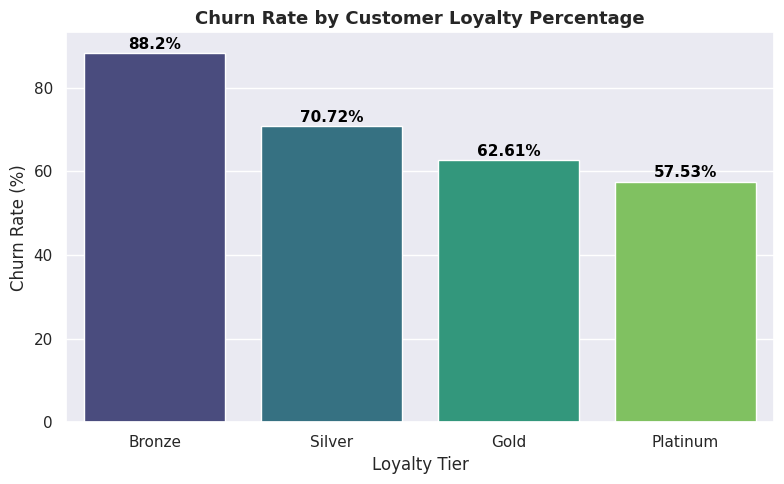

In [40]:
# Churn Rate by Loyalty Tier
plt.figure(figsize=(8, 5))
sns.barplot(x='loyalty_tier', y='churn_rate_percentage', data=customer_retention_and_loyalty, palette='viridis')

plt.title('Churn Rate by Customer Loyalty Percentage', fontsize=13, fontweight='bold')
plt.xlabel('Loyalty Tier', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

for index, row in customer_retention_and_loyalty.iterrows():
    plt.text(index, row['churn_rate_percentage'] + 1, f"{row['churn_rate_percentage']}%",
             color='black', ha="center", fontsize=11, fontweight='bold')

plt.ylim(0, max(customer_retention_and_loyalty['churn_rate_percentage']) + 5)
plt.tight_layout()

plt.show()

/tmp/ipykernel_1522/3902290167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_satisfaction_score', y='referral_source', data=effectiveness_of_referral_source, palette='viridis')


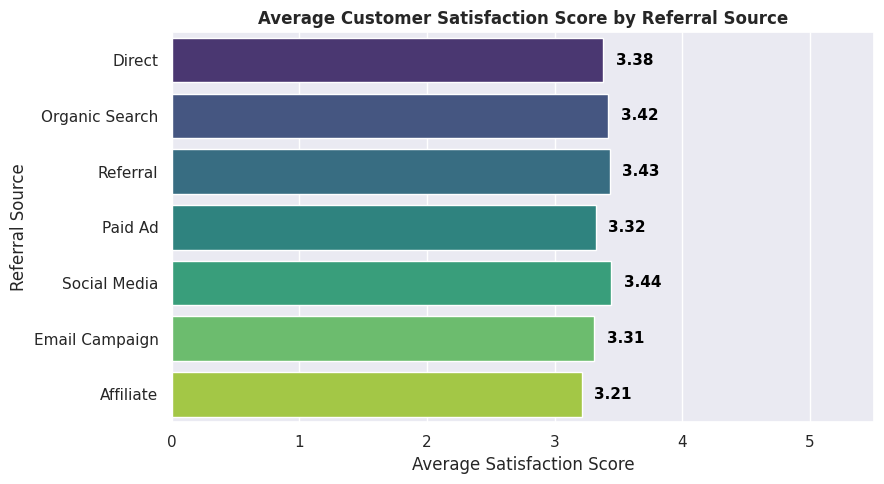

In [33]:
# Refferal Source Effectiveness vs. Satisfaction Score
plt.figure(figsize=(9, 5))

sns.barplot(x='avg_satisfaction_score', y='referral_source', data=effectiveness_of_referral_source, palette='viridis')

plt.title('Average Customer Satisfaction Score by Referral Source', fontweight='bold')
plt.xlabel('Average Satisfaction Score', fontsize=12)
plt.ylabel('Referral Source', fontsize=12)

for index, row in effectiveness_of_referral_source.iterrows():
    plt.text(row['avg_satisfaction_score'] + 0.1, index, f"{row['avg_satisfaction_score']}", color='black', va='center', fontsize=11, fontweight='bold')

plt.xlim(0, 5.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1522/629332386.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='discount_segment', y='avg_return_rate_percentage', data=impact_discount, order=segment_list, palette='viridis')


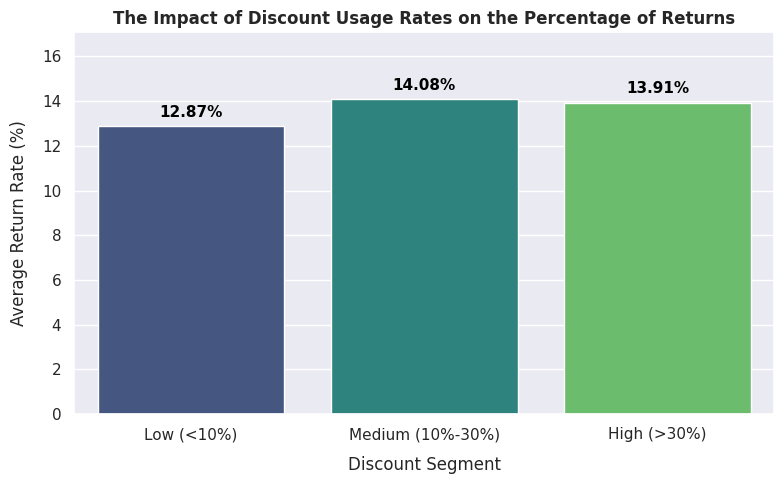

In [34]:
# The Impact of Discount Strategies on Return Rates
plt.figure(figsize=(8, 5))

segment_list  = ['Low (<10%)', 'Medium (10%-30%)', 'High (>30%)']
sns.barplot(x='discount_segment', y='avg_return_rate_percentage', data=impact_discount, order=segment_list, palette='viridis')

plt.title("The Impact of Discount Usage Rates on the Percentage of Returns", fontweight='bold')
plt.xlabel("Discount Segment", fontsize=12, labelpad=10)
plt.ylabel("Average Return Rate (%)", fontsize=12, labelpad=10)

for index, row in impact_discount.iterrows():
    x_pos = segment_list.index(row['discount_segment'])
    val = row['avg_return_rate_percentage']

    plt.text(x_pos, val + 0.3, f"{val:.2f}%",
             color='black', ha='center', va="bottom", fontsize=11, fontweight='bold')

plt.ylim(0, max(impact_discount['avg_return_rate_percentage']) + 3)
plt.tight_layout()
plt.show()

# **Pre-Processing for Machine Learning**

In [35]:
# Feature Selection & Encoding
from sklearn.preprocessing import LabelEncoder

# Duplicate the main DataFrame
ml_df = customer_df.copy()

# Drop columns that are not needed for machine learning modeling
columns_to_drop = ['customer_id', 'signup_date', 'last_purchase_date', 'country']
ml_df = ml_df.drop(columns=[col for col in columns_to_drop if col in ml_df.columns])

#--- LABEL ENCODING ---
# Define a manual sort order for the column
loyalt_map = {'Bronze' : 0, 'Gold' : 1, 'Platinum' : 2}
if 'loyalty_tier' in ml_df.columns:
  ml_df['loyalty_tier'] = ml_df['loyalty_tier'].map(loyalt_map)

categorical_cols = ml_df.select_dtypes(include=['object', 'category']).columns.tolist()

#--- ONE-HOT-ENCODING ---
if categorical_cols:
  ml_df = pd.get_dummies(ml_df, columns=categorical_cols, drop_first=True)

# Convert all boolean columns from the get_dummies result to integers
bool_cols = ml_df.select_dtypes(include=['bool']).columns
ml_df[bool_cols] = ml_df[bool_cols].astype(int)

print("Data Preprocessing Complete! New dataset size:", ml_df.shape)
ml_df.head()

Data Preprocessing Complete! New dataset size: (1200, 48)


,age,customer_lifetime_days,days_since_last_purchase,total_orders,total_spent_usd,avg_order_value_usd,loyalty_tier,discount_usage_rate,return_rate,newsletter_subscribed,...,preferred_payment_method_Debit Card,preferred_payment_method_PayPal,device_type_Mobile,device_type_Tablet,referral_source_Direct,referral_source_Email Campaign,referral_source_Organic Search,referral_source_Paid Ad,referral_source_Referral,referral_source_Social Media
0,35,759,48,115,12871.15,126.16,2.0,0.229,0.084,0,...,0,0,0,0,0,0,0,0,0,1
1,58,1237,251,50,2925.52,64.30,1.0,0.349,0.019,1,...,0,0,1,0,0,0,0,0,0,1
2,43,1248,798,146,9686.17,66.95,2.0,0.186,0.117,1,...,0,0,0,0,0,0,0,1,0,0
3,54,539,504,37,2521.75,70.49,1.0,0.048,0.130,1,...,1,0,1,0,0,0,0,0,1,0
4,30,324,978,6,394.68,69.74,0.0,0.056,0.085,1,...,0,0,1,0,0,1,0,0,0,0


In [36]:
# Separation of Features (X) and Target (y), and Train-Test Split
from sklearn.model_selection import train_test_split

# Separate the feature (X) and the target (Y)
x = ml_df.drop(columns=['churn'])
y = ml_df['churn']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Data separation was successful!")
print(f"Training set size (X_train): {x_train.shape[0]} rows and {x_train.shape[1]} columns")
print(f"Testing set size (X_test): {x_test.shape[0]} rows and {x_test.shape[1]} columns")

Data separation was successful!
Training set size (X_train): 960 rows and 47 columns
Testing set size (X_test): 240 rows and 47 columns


# **Machine Learning Model Training (Churn Prediction)**

In [37]:
# Training Model Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(x_train, y_train)

y.pred = model_rf.predict(x_test)

print("The Machine Learning Model Has Been Successfully Trained!")

accuracy = accuracy_score(y_test, y.pred)
print(f"Model Accuracy Score: {accuracy * 100:.2f}%")

print("Complete Model Performance Report:")
print(classification_report(y_test, y.pred))

The Machine Learning Model Has Been Successfully Trained!
Model Accuracy Score: 98.75%
Complete Model Performance Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        78
           1       0.99      0.99      0.99       162

    accuracy                           0.99       240
   macro avg       0.98      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



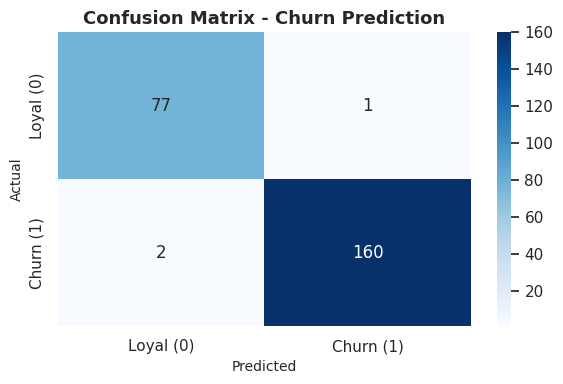

In [38]:
# Visualizing Performance with a Confusion Matrix
cm = confusion_matrix(y_test, y.pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loyal (0)', 'Churn (1)'],
            yticklabels=['Loyal (0)', 'Churn (1)'])

plt.title('Confusion Matrix - Churn Prediction', fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=10)
plt.ylabel('Actual', fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1522/3145894014.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette='magma')


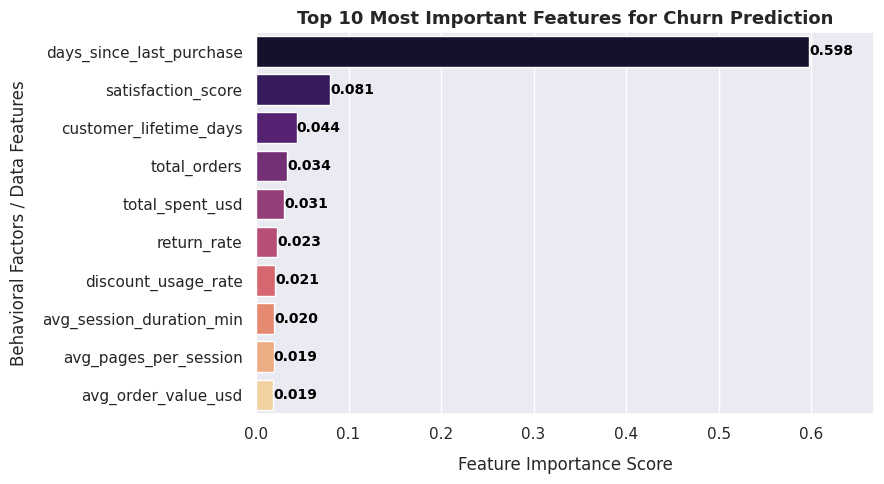

In [39]:
importances = model_rf.feature_importances_
features = x.columns

indices = np.argsort(importances)[::-1]

top_n = min(10, len(features))
sorted_features = [features[i] for i in indices[:top_n]]
sorted_importances = importances[indices][:top_n]

plt.figure(figsize=(9, 5))
sns.barplot(x=sorted_importances, y=sorted_features, palette='magma')

plt.title('Top 10 Most Important Features for Churn Prediction', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12, labelpad=10)
plt.ylabel('Behavioral Factors / Data Features', fontsize=12, labelpad=10)

for index, value in enumerate(sorted_importances):
  plt.text(value, index, f"{value:.3f}",
           color='black', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, max(sorted_importances) + 0.07)
plt.tight_layout()
plt.show()